<a href="https://colab.research.google.com/github/MuzaffarIshmurotov/German-Bank/blob/main/German_Bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


np.random.seed(42)

In [73]:
df = pd.read_csv('/home/claude/credit_scoring_practice/german_credit.csv')

print(f"✓ Data loaded: {df.shape}")

✓ Data loaded: (1000, 21)


In [74]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,A13,44,A34,A41,13828,A61,A72,3,A92,A102,...,A121,24,A143,A152,3,A174,1,A191,A202,0
1,A13,63,A32,A42,11825,A65,A72,2,A93,A101,...,A124,25,A141,A153,3,A174,2,A191,A202,1
2,A11,32,A32,A41,18478,A61,A74,3,A92,A102,...,A124,62,A141,A153,1,A171,1,A192,A201,1
3,A11,45,A34,A41,4174,A64,A74,4,A91,A102,...,A123,57,A143,A151,1,A174,1,A191,A202,0
4,A12,36,A31,A42,15951,A61,A73,4,A91,A102,...,A123,72,A142,A152,1,A171,1,A191,A202,0


### prepare feature

In [75]:
numerical_features = ['duration', 'credit_amount', 'installment_rate',
                      'residence_since', 'age', 'existing_credits', 'num_dependents']

categorical_features =[col for col in df.columns
                       if col not in numerical_features and col != 'target']

In [76]:
df_encoded = df.copy()
for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])

print(f"✓ Features encoded")

✓ Features encoded


### Split x and y

In [81]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

print(f"✓ Features and target split")

✓ Features and target split


### Train test split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"✓ Train test split")


✓ Train test split


### Scale feature

In [87]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Features scaled")

✓ Features scaled


### Train model

In [88]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print(f"✓ Model trained")

✓ Model trained


### Evaluate

In [89]:
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"✓ Model evaluated")

✓ Model evaluated


In [91]:
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


Accuracy: 0.7033
AUC-ROC:  0.5189

Confusion Matrix:
[[  0  89]
 [  0 211]]


In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

Creating Visualization 1: Data Distribution...
✓ Saved: viz1_data_distribution.png


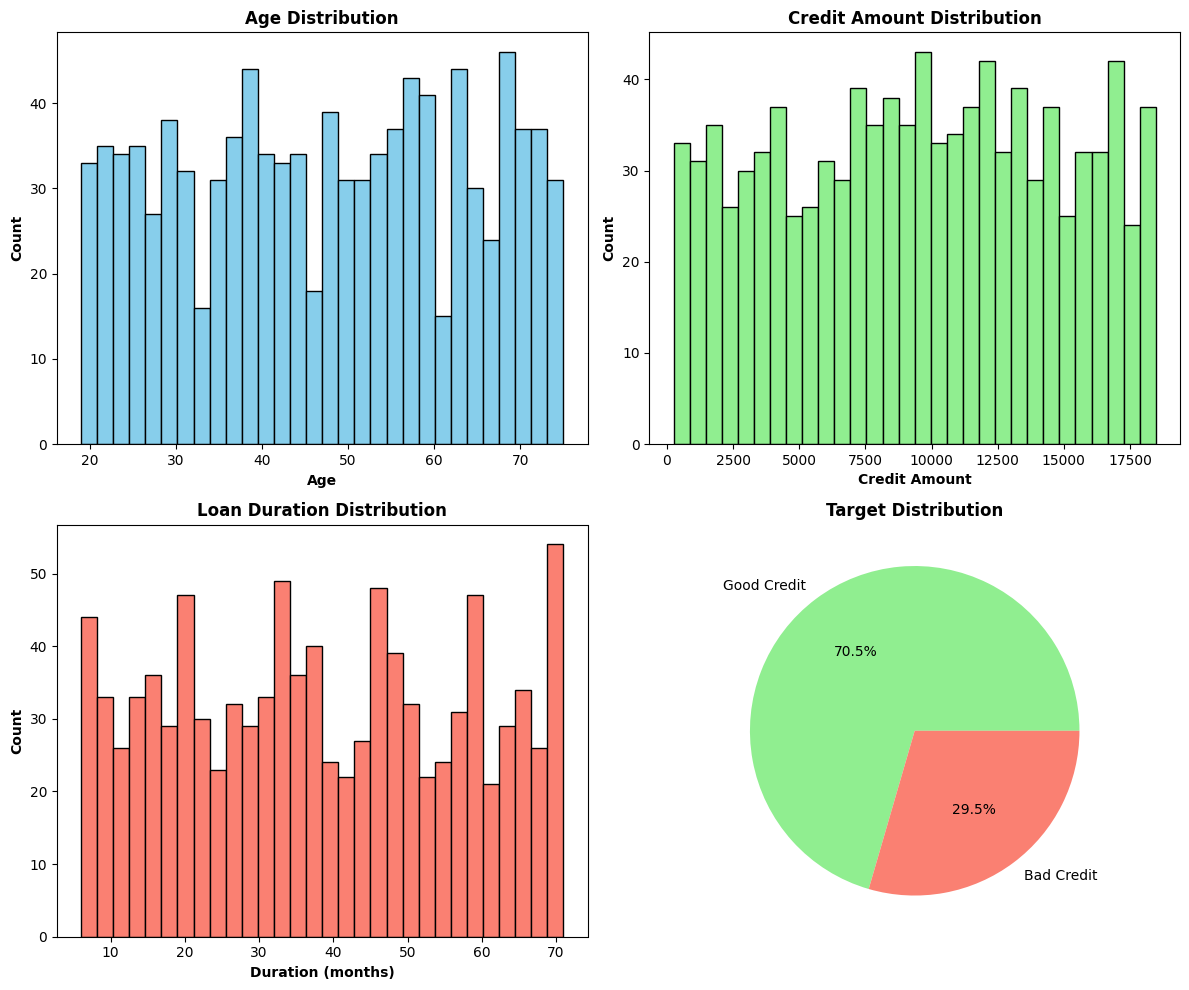

In [99]:
print("Creating Visualization 1: Data Distribution...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Age distribution
axes[0, 0].hist(df['age'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Age', fontweight='bold')
axes[0, 0].set_ylabel('Count', fontweight='bold')
axes[0, 0].set_title('Age Distribution', fontweight='bold')

# Credit amount distribution
axes[0, 1].hist(df['credit_amount'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_xlabel('Credit Amount', fontweight='bold')
axes[0, 1].set_ylabel('Count', fontweight='bold')
axes[0, 1].set_title('Credit Amount Distribution', fontweight='bold')

# Duration distribution
axes[1, 0].hist(df['duration'], bins=30, color='salmon', edgecolor='black')
axes[1, 0].set_xlabel('Duration (months)', fontweight='bold')
axes[1, 0].set_ylabel('Count', fontweight='bold')
axes[1, 0].set_title('Loan Duration Distribution', fontweight='bold')

# Target distribution (pie chart)
target_counts = df['target'].value_counts()
axes[1, 1].pie(target_counts, labels=['Good Credit', 'Bad Credit'],
               autopct='%1.1f%%', colors=['lightgreen', 'salmon'])
axes[1, 1].set_title('Target Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('/home/claude/credit_scoring_practice/viz1_data_distribution.png', dpi=150)
print("✓ Saved: viz1_data_distribution.png")
plt.show()

Creating Visualization 2: Age vs Credit Amount...
✓ Saved: viz2_age_vs_amount.png


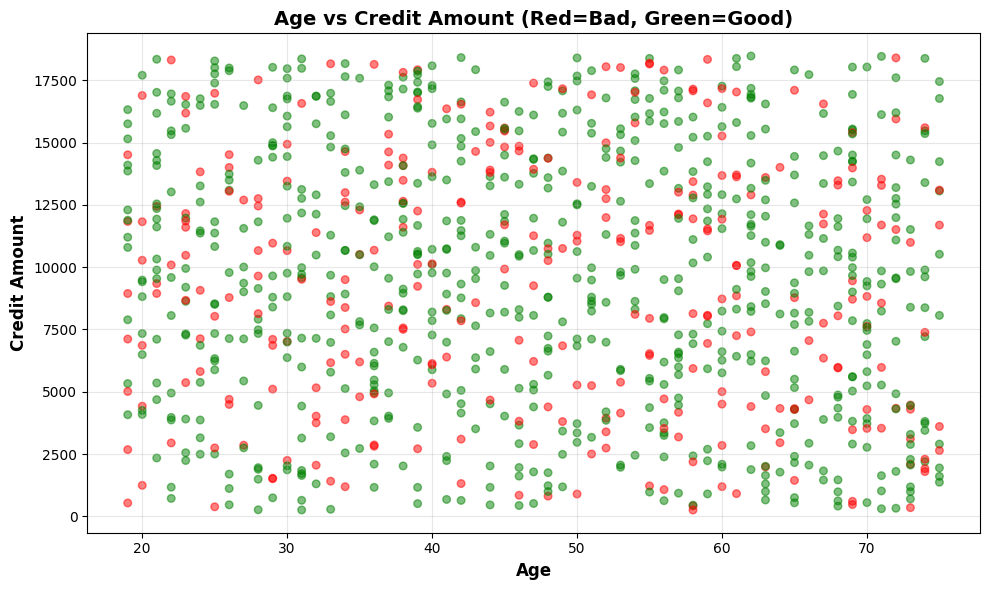

In [100]:
print("Creating Visualization 2: Age vs Credit Amount...")

plt.figure(figsize=(10, 6))
colors = ['red' if t == 0 else 'green' for t in df['target']]
plt.scatter(df['age'], df['credit_amount'], c=colors, alpha=0.5, s=30)
plt.xlabel('Age', fontweight='bold', fontsize=12)
plt.ylabel('Credit Amount', fontweight='bold', fontsize=12)
plt.title('Age vs Credit Amount (Red=Bad, Green=Good)', fontweight='bold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/credit_scoring_practice/viz2_age_vs_amount.png', dpi=150)
print("✓ Saved: viz2_age_vs_amount.png")
plt.show()

Creating Visualization 3: Correlation Heatmap...
✓ Saved: viz3_correlation.png


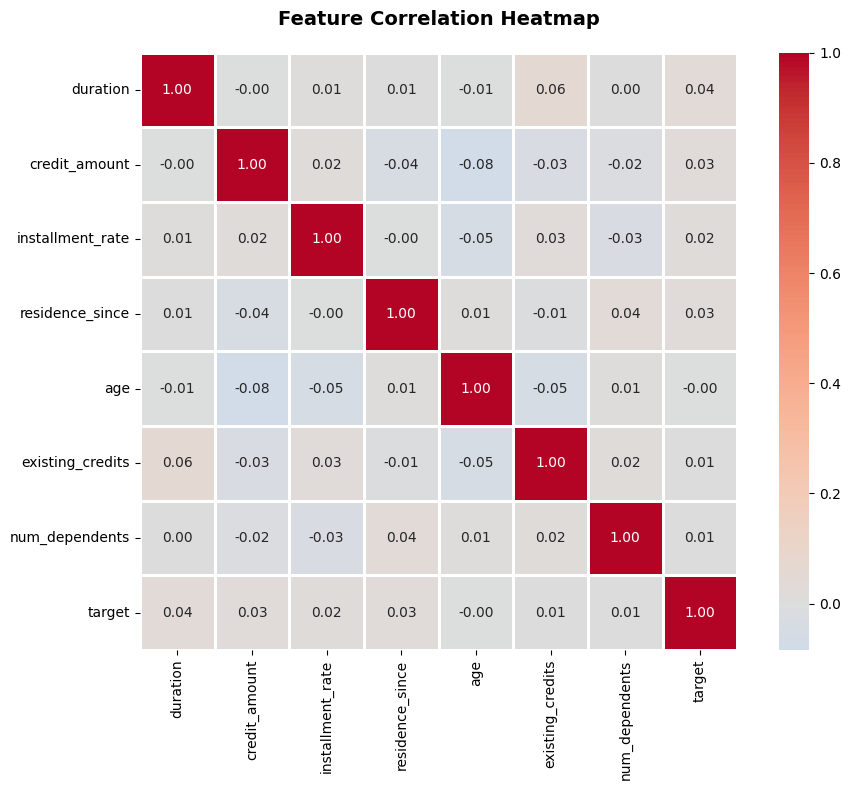

In [101]:
print("Creating Visualization 3: Correlation Heatmap...")

# Select only numerical columns
numerical_cols = ['duration', 'credit_amount', 'installment_rate',
                  'residence_since', 'age', 'existing_credits', 'num_dependents', 'target']
corr_data = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Heatmap', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('/home/claude/credit_scoring_practice/viz3_correlation.png', dpi=150)
print("✓ Saved: viz3_correlation.png")
plt.show()

Creating Visualization 4: Confusion Matrix...
✓ Saved: viz4_confusion_matrix.png


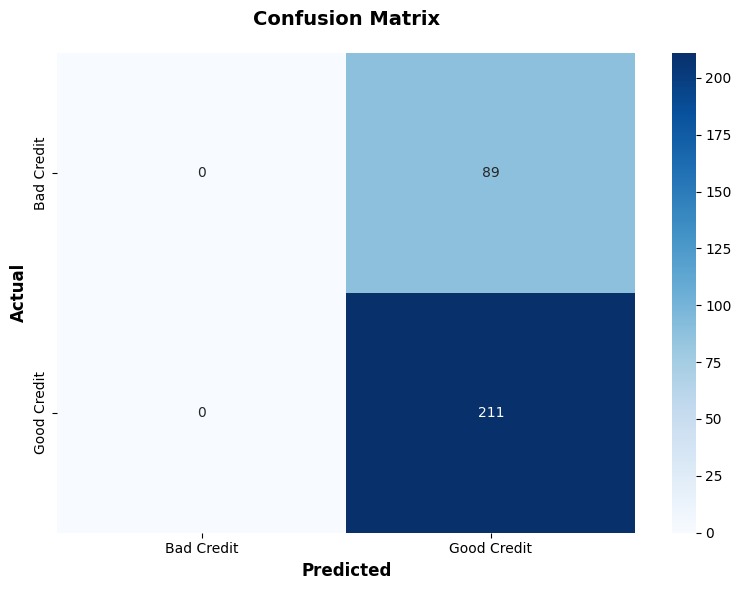

In [102]:
print("Creating Visualization 4: Confusion Matrix...")

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Bad Credit', 'Good Credit'],
            yticklabels=['Bad Credit', 'Good Credit'])
plt.xlabel('Predicted', fontweight='bold', fontsize=12)
plt.ylabel('Actual', fontweight='bold', fontsize=12)
plt.title('Confusion Matrix', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('/home/claude/credit_scoring_practice/viz4_confusion_matrix.png', dpi=150)
print("✓ Saved: viz4_confusion_matrix.png")
plt.show()

Creating Visualization 5: ROC Curve...
✓ Saved: viz5_roc_curve.png


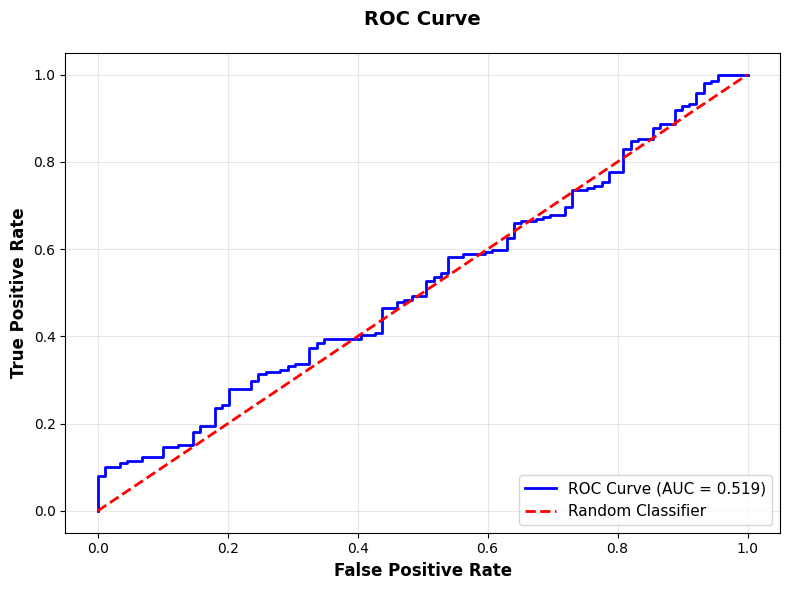

In [103]:
print("Creating Visualization 5: ROC Curve...")

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
plt.ylabel('True Positive Rate', fontweight='bold', fontsize=12)
plt.title('ROC Curve', fontweight='bold', fontsize=14, pad=20)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/credit_scoring_practice/viz5_roc_curve.png', dpi=150)
print("✓ Saved: viz5_roc_curve.png")
plt.show()

✓ Saved: viz6_feature_importance.png


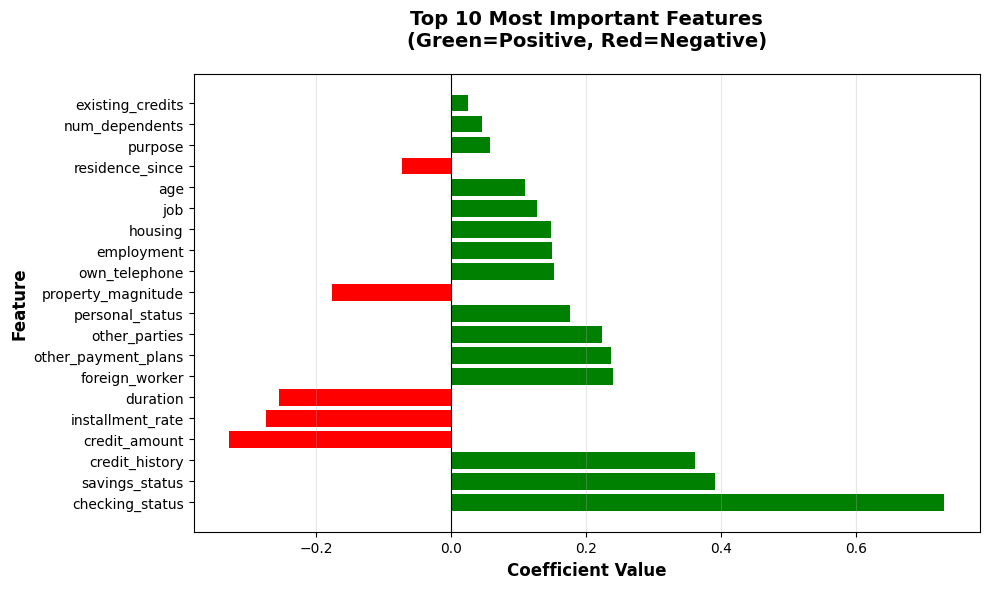

In [104]:
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in feature_importance['coefficient']]
plt.barh(feature_importance['feature'], feature_importance['coefficient'], color=colors)
plt.xlabel('Coefficient Value', fontweight='bold', fontsize=12)
plt.ylabel('Feature', fontweight='bold', fontsize=12)
plt.title('Top 10 Most Important Features\n(Green=Positive, Red=Negative)',
          fontweight='bold', fontsize=14, pad=20)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/credit_scoring_practice/viz6_feature_importance.png', dpi=150)
print("✓ Saved: viz6_feature_importance.png")
plt.show()

✓ Saved: viz7_probability_dist.png


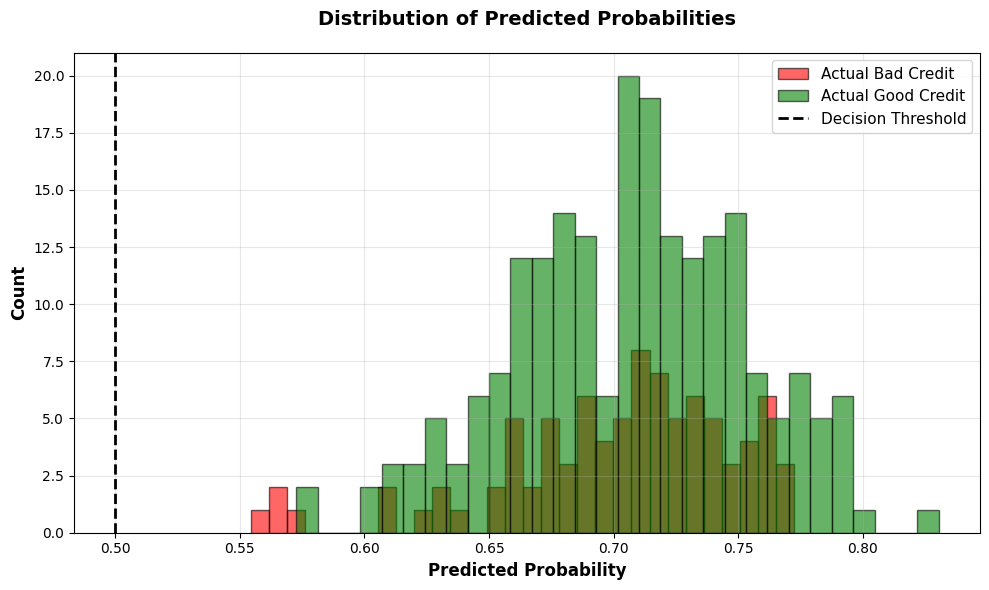

In [105]:
plt.figure(figsize=(10, 6))
plt.hist(y_test_proba[y_test == 0], bins=30, alpha=0.6, color='red',
         label='Actual Bad Credit', edgecolor='black')
plt.hist(y_test_proba[y_test == 1], bins=30, alpha=0.6, color='green',
         label='Actual Good Credit', edgecolor='black')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
plt.xlabel('Predicted Probability', fontweight='bold', fontsize=12)
plt.ylabel('Count', fontweight='bold', fontsize=12)
plt.title('Distribution of Predicted Probabilities', fontweight='bold', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/credit_scoring_practice/viz7_probability_dist.png', dpi=150)
print("✓ Saved: viz7_probability_dist.png")
plt.show()

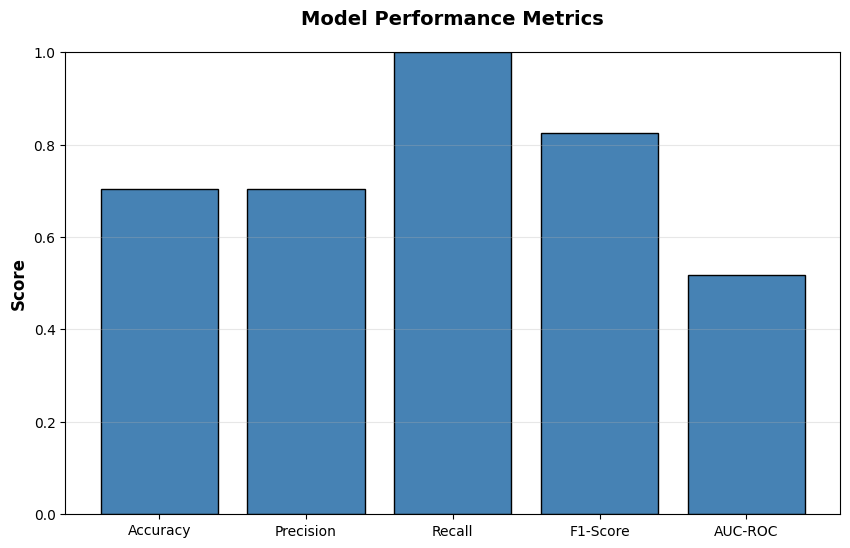

In [106]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-Score': f1_score(y_test, y_test_pred),
    'AUC-ROC': roc_auc_score(y_test, y_test_proba)
}

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics.keys(), metrics.values(), color='steelblue', edgecolor='black')
plt.ylabel('Score', fontweight='bold', fontsize=12)
plt.title('Model Performance Metrics', fontweight='bold', fontsize=14, pad=20)
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.show()